In [3]:
import re
import matplotlib.pyplot as plt
import numpy as np

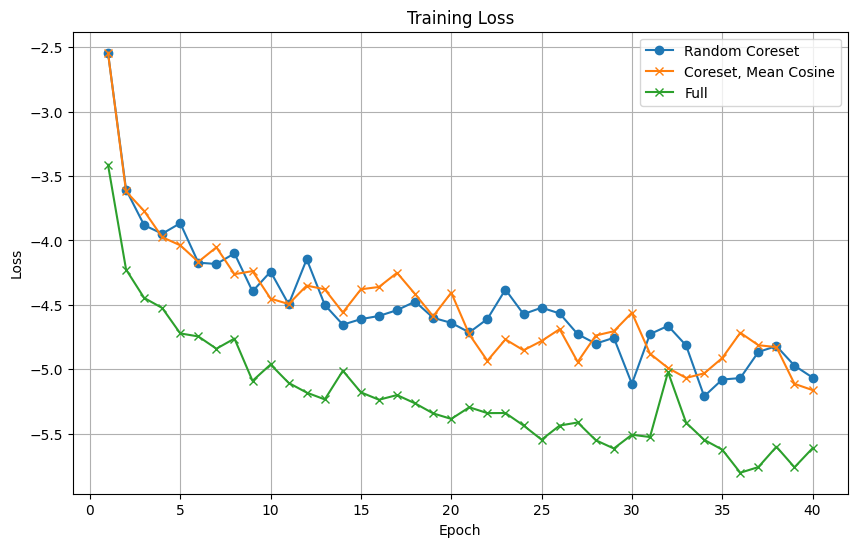

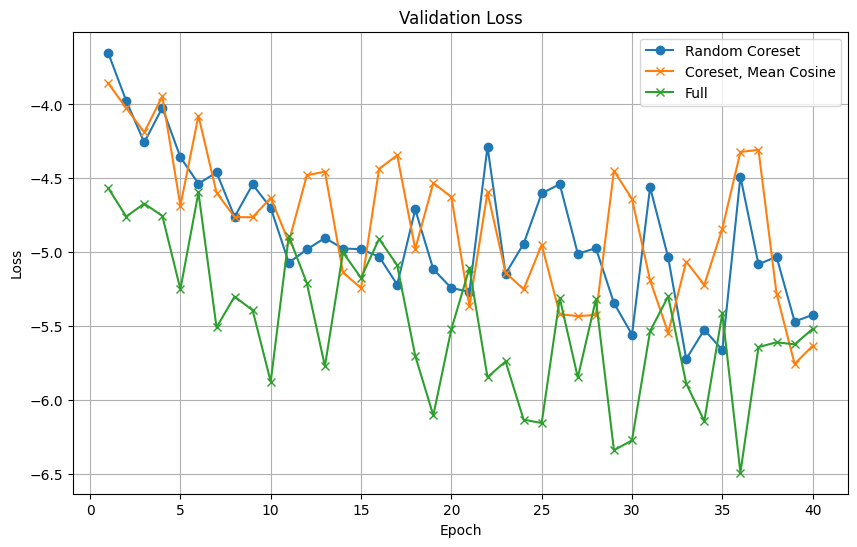

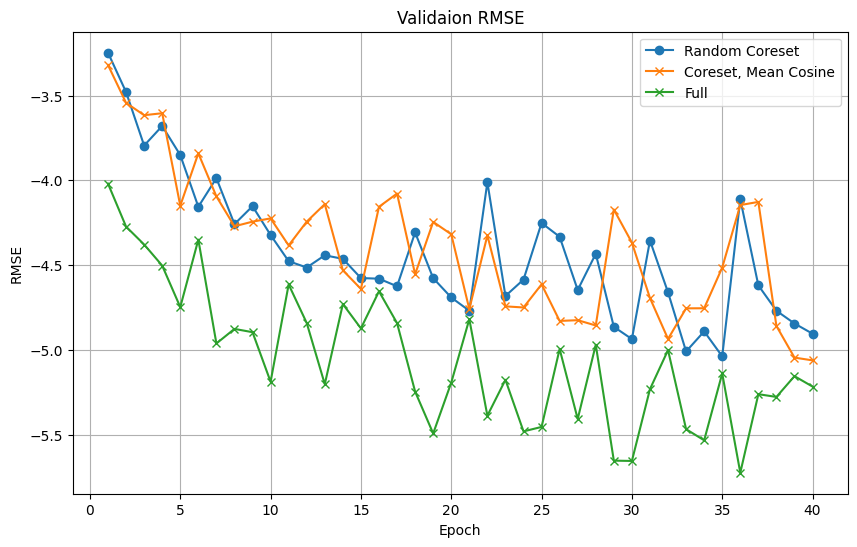

In [10]:

def read_log_file(file_path):
    with open(file_path, 'r') as f:
        return ''.join(f.readlines())

def extract_losses(log_text, train_loss_pattern, val_loss_pattern):
    train_losses = re.findall(train_loss_pattern, log_text)
    val_losses = re.findall(val_loss_pattern, log_text)
    epochs_train, losses_train, rmse_train = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in train_losses])
    epochs_val, losses_val, rmse_val = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in val_losses])
    return epochs_train, losses_train, rmse_train, epochs_val, losses_val, rmse_val


def plot_losses(log_files, train_loss_pattern, val_loss_pattern, plot_type='train_loss'):
    plt.figure(figsize=(10, 6))
    for log_file in log_files:
        log_text = read_log_file(log_file['path'])
        epochs_train, losses_train, rmse_train, epochs_val, losses_val, rmse_val = extract_losses(log_text, train_loss_pattern, val_loss_pattern)
        
        if plot_type == 'train_loss':
            plotting_value = losses_train
            ylabel = 'Loss'
            name = 'Training Loss'
        elif plot_type == 'val_loss':
            plotting_value = losses_val
            ylabel = 'Loss'
            name = 'Validation Loss'
        elif plot_type == 'val_rmse':
            plotting_value = rmse_val
            ylabel = 'RMSE'
            name = 'Validaion RMSE'
        
        plt.plot(epochs_train, np.log(plotting_value), label=log_file['label'], marker=log_file.get('marker', 'o'))
    
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(name)
    plt.legend()
    plt.grid(True)
    plt.show()

# Patterns to extract the training and validation loss information
train_loss_pattern = r"Epoch: (\d+); metrics on train: {'berhu_loss': ([\d.]+), 'rmse': ([\d.]+)"
val_loss_pattern = r"Epoch (\d{4}): validation metrics: {'berhu_loss': ([\d.]+), 'rmse': ([\d.]+)"

# List of log files with labels
log_files = [
    {'path': '/home/MultiModalCoreset/multimae/logs/rgb-semseg-coreset_random_20.log', 'label': 'Random Coreset', 'marker': 'o'},
   # {'path': '/home/MultiModalCoreset/multimae/logs/rgb-semseg-coreset_20.log', 'label': 'Coreset, Full L2', 'marker': 'x'},
    {'path': '/home/MultiModalCoreset/multimae/logs/coreset_mean_20.log', 'label': 'Coreset, Mean Cosine', 'marker': 'x'},
  #  {'path': '/home/MultiModalCoreset/multimae/logs/coreset_sum_20.log', 'label': 'Coreset, Sum Cosine', 'marker': 'x'},
    {'path': '/home/MultiModalCoreset/multimae/logs/multimae.log', 'label': 'Full', 'marker': 'x'}
]

# Plot the losses
types = ['train_loss', 'val_loss', 'val_rmse']

for plot_type in types:
    plot_losses(log_files, train_loss_pattern, val_loss_pattern, plot_type)


In [3]:

with open('/home/MultiModalCoreset/multimae/logs/rgb-semseg-coreset_random_20.log', 'r') as f:
    rgb_text = ''.join(f.readlines())

with open('/home/MultiModalCoreset/multimae/logs/rgb-semseg-coreset_20.log', 'r') as f:
    semseg_text = ''.join(f.readlines())

with open('/home/MultiModalCoreset/multimae/logs/multimae.log', 'r') as f:
    multi_text = ''.join(f.readlines())

# Find all matches
train_losses_rgb = re.findall(train_loss_pattern, rgb_text)
val_losses_rgb = re.findall(val_loss_pattern, rgb_text)

train_losses_semseg = re.findall(train_loss_pattern, semseg_text)
val_losses_semseg = re.findall(val_loss_pattern, semseg_text)

train_losses_multi = re.findall(train_loss_pattern, multi_text)
val_losses_multi = re.findall(val_loss_pattern, multi_text)

# Convert to numeric and separate epochs and losses
epochs_train, losses_train_rgb, rmse_train_rgb = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in train_losses_rgb])
epochs_val, losses_val_rgb, rmse_val_rgb = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in val_losses_rgb])

epochs_train, losses_train_semseg, rmse_train_semseg = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in train_losses_semseg])
epochs_val, losses_val_semseg, rmse_val_semseg = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in val_losses_semseg])

epochs_train, losses_train_multi, rmse_train_multi = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in train_losses_multi])
epochs_val, losses_val_multi, rmse_val_multi = zip(*[(int(epoch), float(loss), float(rmse)) for epoch, loss, rmse in val_losses_multi])


# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train, np.log(losses_train_rgb), label='Random Coreset', marker='o')
plt.plot(epochs_train, np.log(losses_train_semseg), label='Coreset', marker='x')
plt.plot(epochs_train, np.log(losses_train_multi), label='Full', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

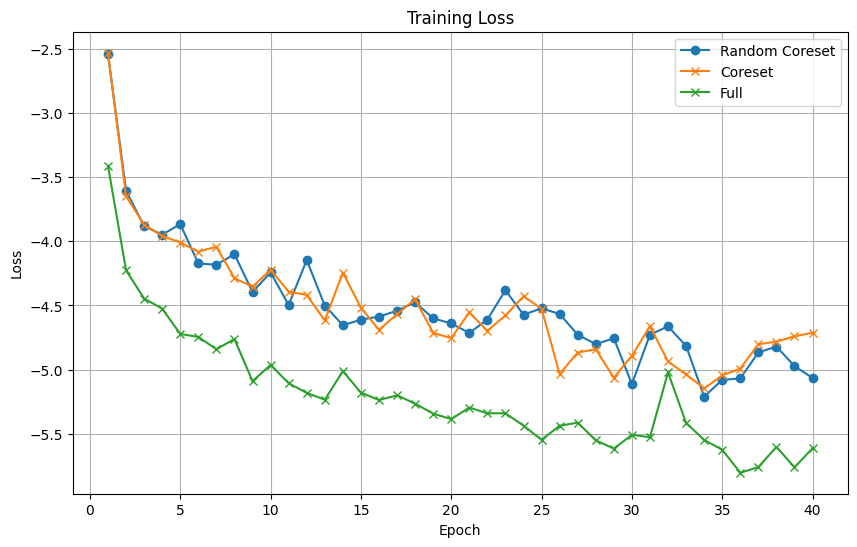

In [5]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train, np.log(losses_train_rgb), label='Random Coreset', marker='o')
plt.plot(epochs_train, np.log(losses_train_semseg), label='Coreset', marker='x')
plt.plot(epochs_train, np.log(losses_train_multi), label='Full', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

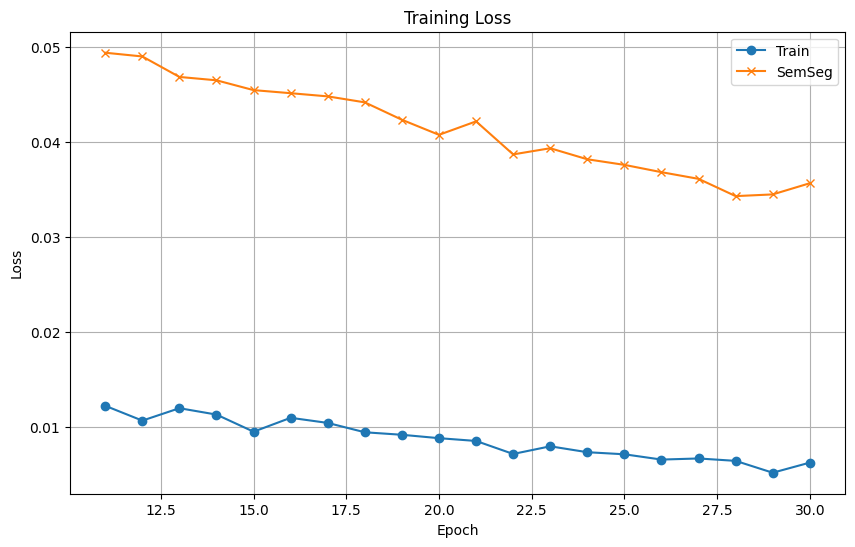

In [8]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train[10:], losses_train_rgb[10:], label='Train', marker='o')
plt.plot(epochs_train[10:], losses_train_semseg[10:], label='SemSeg', marker='x')
#plt.plot(epochs_train, np.log(losses_train_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

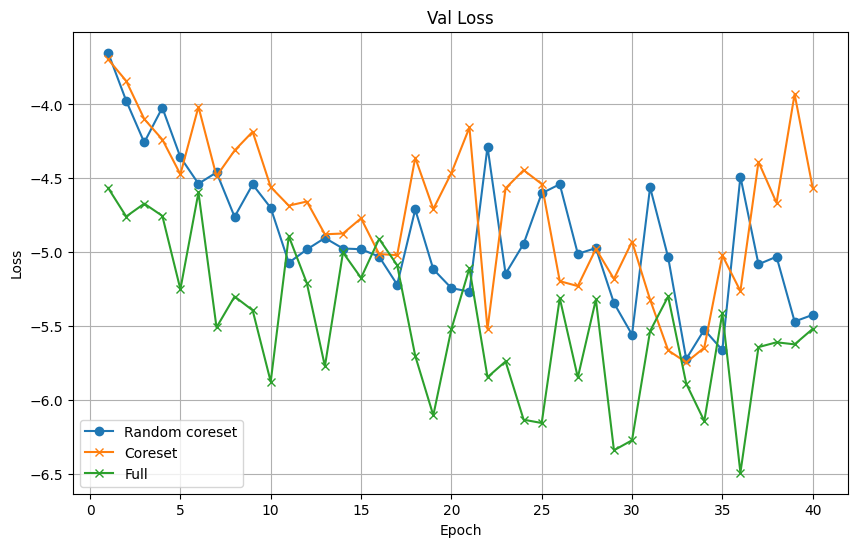

In [6]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_train, np.log(losses_val_rgb), label='Random coreset', marker='o')
plt.plot(epochs_train, np.log(losses_val_semseg), label='Coreset', marker='x')
plt.plot(epochs_train, np.log(losses_val_multi), label='Full', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Val Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
losses_val_multi[20:], losses_train_multi[20:]

((0.2549420394003391,
  0.25494165495038035,
  0.25494163781404494,
  0.254941588640213,
  0.25494159013032913,
  0.25494153797626495,
  0.2549432650208473,
  0.2549414739012718,
  0.2549413561820984,
  0.2549417831003666),
 (0.27016105460814943,
  0.27066569313024863,
  0.27077851043297696,
  0.27078800721046253,
  0.2707932295707556,
  0.27081722235068295,
  0.2707016320564808,
  0.2708430162607095,
  0.2707531398687607,
  0.2708076543532885))

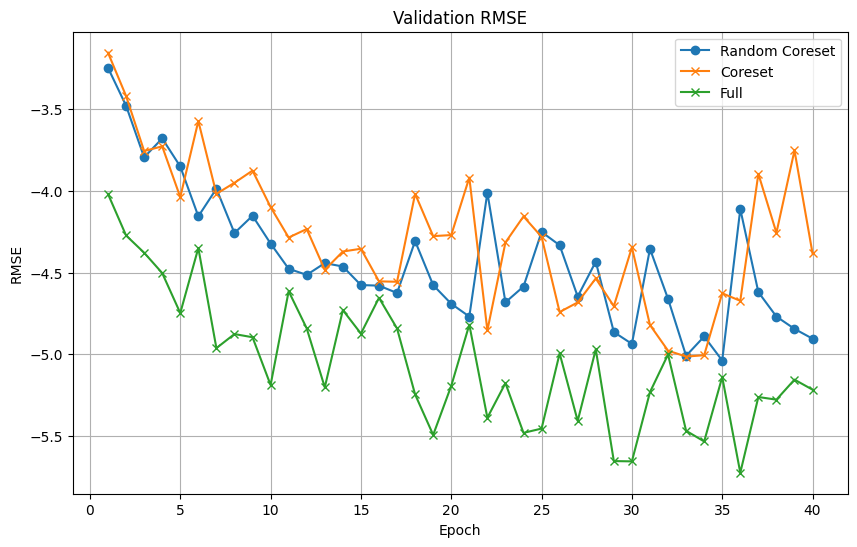

In [7]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_val, np.log(rmse_val_rgb), label='Random Coreset', marker='o')
plt.plot(epochs_val, np.log(rmse_val_semseg), label='Coreset', marker='x')
plt.plot(epochs_val, np.log(rmse_val_multi), label='Full', marker='x')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Validation RMSE')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
print(f" min rmse random: {np.min(rmse_val_rgb)}, \n min rmse coreset: {np.min(rmse_val_semseg)} \n min rmse full  {np.min(losses_val_multi)}")

 min rmse random: 0.0064851737581193445, 
 min rmse coreset: 0.006643609656020999 
 min rmse full  0.0015169858961598948


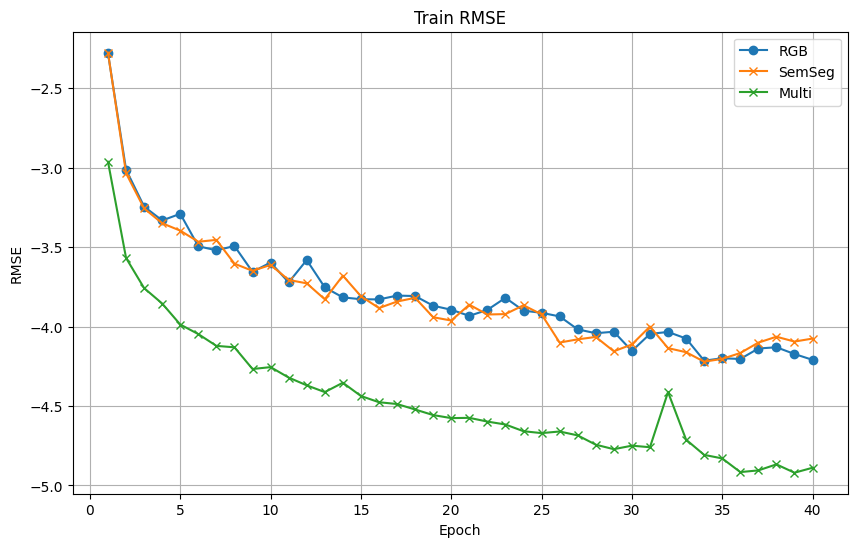

In [9]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs_val, np.log(rmse_train_rgb), label='RGB', marker='o')
plt.plot(epochs_val, np.log(rmse_train_semseg), label='SemSeg', marker='x')
plt.plot(epochs_val, np.log(rmse_train_multi), label='Multi', marker='x')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Train RMSE')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
np.min(losses_val_rgb), np.min(losses_val_semseg), np.min(losses_val_multi)

(263.811572265625, 206.81939544677735, 204.46053314208984)